In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

In [3]:
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory
import cv2
import os
for dirname, _, filenames in os.walk(r'C:\Users\Welcome\Documents\Brain_Tumor\archive'):
    for filename in filenames:
       print(os.path.join(dirname, filename))

C:\Users\Welcome\Documents\Brain_Tumor\archive\Testing\glioma\Te-glTr_0000.jpg
C:\Users\Welcome\Documents\Brain_Tumor\archive\Testing\glioma\Te-glTr_0001.jpg
C:\Users\Welcome\Documents\Brain_Tumor\archive\Testing\glioma\Te-glTr_0002.jpg
C:\Users\Welcome\Documents\Brain_Tumor\archive\Testing\glioma\Te-glTr_0003.jpg
C:\Users\Welcome\Documents\Brain_Tumor\archive\Testing\glioma\Te-glTr_0004.jpg
C:\Users\Welcome\Documents\Brain_Tumor\archive\Testing\glioma\Te-glTr_0005.jpg
C:\Users\Welcome\Documents\Brain_Tumor\archive\Testing\glioma\Te-glTr_0006.jpg
C:\Users\Welcome\Documents\Brain_Tumor\archive\Testing\glioma\Te-glTr_0007.jpg
C:\Users\Welcome\Documents\Brain_Tumor\archive\Testing\glioma\Te-glTr_0008.jpg
C:\Users\Welcome\Documents\Brain_Tumor\archive\Testing\glioma\Te-glTr_0009.jpg
C:\Users\Welcome\Documents\Brain_Tumor\archive\Testing\glioma\Te-gl_0010.jpg
C:\Users\Welcome\Documents\Brain_Tumor\archive\Testing\glioma\Te-gl_0011.jpg
C:\Users\Welcome\Documents\Brain_Tumor\archive\Testing\g

In [4]:
import keras
from keras.models import Sequential
from keras.layers import Conv2D,Flatten,Dense,MaxPooling2D,Dropout
from sklearn.metrics import accuracy_score

In [5]:
import ipywidgets as widgets
import io
from PIL import Image
import tqdm
from sklearn.model_selection import train_test_split
import cv2
from sklearn.utils import shuffle
import tensorflow as tf

In [6]:
x_train = []
y_train = []
image_size = 256
labels = ['glioma','meningioma','notumor','pituitary']
for i in labels:
    folderPath = os.path.join(r'C:\Users\Welcome\Documents\Brain_Tumor\archive\Training',i)
    for j in os.listdir(folderPath):
        img = cv2.imread(os.path.join(folderPath,j))
        img = cv2.resize(img,(image_size,image_size))
        x_train.append(img)
        y_train.append(i)

In [7]:
x_train = np.array(x_train)
y_train = np.array(y_train)

In [8]:
import numpy as np

# Get unique class labels and their counts
unique_classes, class_counts = np.unique(y_train, return_counts=True)

# Display class names and their counts
for class_name, count in zip(unique_classes, class_counts):
    print(f"Class: {class_name}, Count: {count}")


Class: glioma, Count: 1321
Class: meningioma, Count: 1339
Class: notumor, Count: 1595
Class: pituitary, Count: 1457


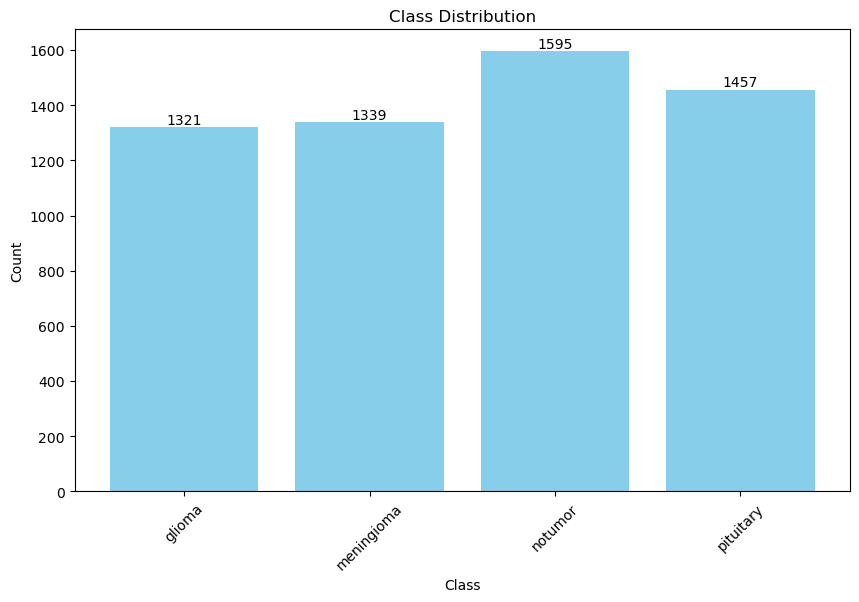

In [9]:
import matplotlib.pyplot as plt

# Get unique class labels and their counts
unique_classes, class_counts = np.unique(y_train, return_counts=True)

# Plotting the bar plot
plt.figure(figsize=(10, 6))
bars = plt.bar(unique_classes, class_counts, color='skyblue')

# Annotating each bar with its count
for bar, count in zip(bars, class_counts):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5, str(count), ha='center', va='bottom')

plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45)  # Rotate class labels for better visibility
plt.show()


In [10]:
x_test = []
y_test = []

for i in labels:
    folderPath = os.path.join(r'C:\Users\Welcome\Documents\Brain_Tumor\archive\Testing', i)
    for j in os.listdir(folderPath):
        img = cv2.imread(os.path.join(folderPath, j))
        img = cv2.resize(img, (image_size, image_size))
        x_test.append(img)
        y_test.append(i)

# Convert lists to numpy arrays
x_test = np.array(x_test)
y_test = np.array(y_test)


In [11]:
x_train,y_train = shuffle(x_train,y_train,random_state=101)
x_train.shape

(5712, 256, 256, 3)

In [13]:
import numpy as np

# Get unique class labels and their counts
unique_classes, class_counts = np.unique(y_test, return_counts=True)

# Display class names and their counts
for class_name, count in zip(unique_classes, class_counts):
    print(f"Class: {class_name}, Count: {count}")


Class: glioma, Count: 300
Class: meningioma, Count: 306
Class: notumor, Count: 405
Class: pituitary, Count: 300


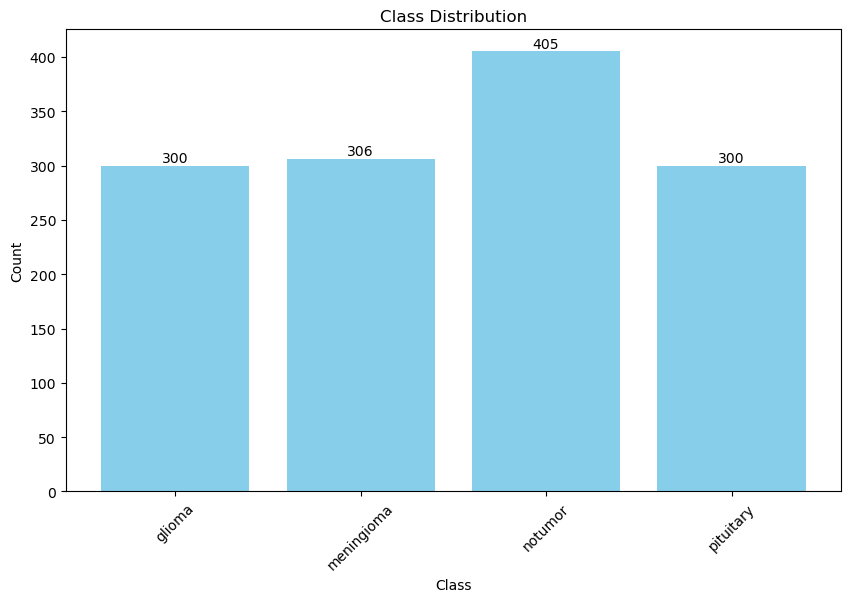

In [14]:
import matplotlib.pyplot as plt

# Get unique class labels and their counts
unique_classes, class_counts = np.unique(y_test, return_counts=True)

# Plotting the bar plot
plt.figure(figsize=(10, 6))
bars = plt.bar(unique_classes, class_counts, color='skyblue')

# Annotating each bar with its count
for bar, count in zip(bars, class_counts):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5, str(count), ha='center', va='bottom')

plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45)  # Rotate class labels for better visibility
plt.show()


In [15]:
y_train_new = []
for i in y_train:
    y_train_new.append(labels.index(i))

In [16]:
y_train=y_train_new
y_train = tf.keras.utils.to_categorical(y_train)

In [17]:
y_test_new = []
for i in y_test:
    y_test_new.append(labels.index(i))
y_test=y_test_new
y_test = tf.keras.utils.to_categorical(y_test)

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense
model = Sequential()
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(256, 256, 3)))
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.3))
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(Dropout(0.3))
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.3))
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.3))
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(Conv2D(256, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.3))
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(4, activation='softmax'))


In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 254, 254, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 252, 252, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 126, 126, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 126, 126, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 124, 124, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 122, 122, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 122, 122, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 61, 61, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 61, 61, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 59, 59, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 57, 57, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 55, 55, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 27, 27, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 27, 27, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 25, 25, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 23, 23, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 11, 11, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 11, 11, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 30976)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │      15,860,224 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 512)                 │         262,656 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 17,029,956 (64.96 MB)

 Trainable params: 17,029,956 (64.96 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.compile(loss='categorical_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [21]:
history = model.fit(x_train, y_train, epochs=18, validation_split=0.1)

Epoch 1/18
161/161 ━━━━━━━━━━━━━━━━━━━━ 345s 2s/step - accuracy: 0.3814 - loss: 3.5537 - val_accuracy: 0.6171 - val_loss: 0.9114
Epoch 2/18
161/161 ━━━━━━━━━━━━━━━━━━━━ 355s 2s/step - accuracy: 0.7180 - loss: 0.6860 - val_accuracy: 0.4371 - val_loss: 1.8842
Epoch 3/18
161/161 ━━━━━━━━━━━━━━━━━━━━ 353s 2s/step - accuracy: 0.7770 - loss: 0.5540 - val_accuracy: 0.5157 - val_loss: 1.1470
Epoch 4/18
161/161 ━━━━━━━━━━━━━━━━━━━━ 355s 2s/step - accuracy: 0.8291 - loss: 0.4255 - val_accuracy: 0.5490 - val_loss: 1.0306
Epoch 5/18
161/161 ━━━━━━━━━━━━━━━━━━━━ 351s 2s/step - accuracy: 0.8629 - loss: 0.3609 - val_accuracy: 0.5647 - val_loss: 1.2193
Epoch 6/18
161/161 ━━━━━━━━━━━━━━━━━━━━ 355s 2s/step - accuracy: 0.8846 - loss: 0.3062 - val_accuracy: 0.5035 - val_loss: 1.8268
Epoch 7/18
161/161 ━━━━━━━━━━━━━━━━━━━━ 379s 2s/step - accuracy: 0.8918 - loss: 0.2848 - val_accuracy: 0.8636 - val_loss: 0.4149
Epoch 8/18
161/161 ━━━━━━━━━━━━━━━━━━━━ 378s 2s/step - accuracy: 0.9068 - loss: 0.2513 - val_accu

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [24]:
# Get the predicted labels for the test data
y_pred = model.predict(x_test)
y_pred

41/41 ━━━━━━━━━━━━━━━━━━━━ 18s 438ms/step


array([[9.9997926e-01, 1.2817928e-06, 7.1937070e-06, 1.2278570e-05],
       [9.9960381e-01, 3.4709487e-06, 3.9211923e-04, 5.3176154e-07],
       [9.9437416e-01, 3.9646176e-07, 5.6226016e-03, 2.8308662e-06],
       ...,
       [3.9464271e-06, 2.5161933e-03, 6.1390089e-04, 9.9686593e-01],
       [1.7084874e-02, 7.1653834e-05, 3.1592026e-05, 9.8281187e-01],
       [3.1979508e-07, 5.2137341e-04, 8.7572429e-05, 9.9939072e-01]],
      dtype=float32)

In [25]:
# Convert predicted probabilities to class labels
y_pred_classes = np.argmax(y_pred, axis=1)
y_pred_classes

array([0, 0, 0, ..., 3, 3, 3], dtype=int64)

In [26]:
# Convert one-hot encoded true labels to class labels
y_true_classes = np.argmax(y_test, axis=1)
y_true_classes

array([0, 0, 0, ..., 3, 3, 3], dtype=int64)

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report

In [28]:
conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)
conf_matrix

array([[280,  16,   1,   3],
       [ 28, 239,  17,  22],
       [  5,   3, 391,   6],
       [  4,   3,   2, 291]], dtype=int64)

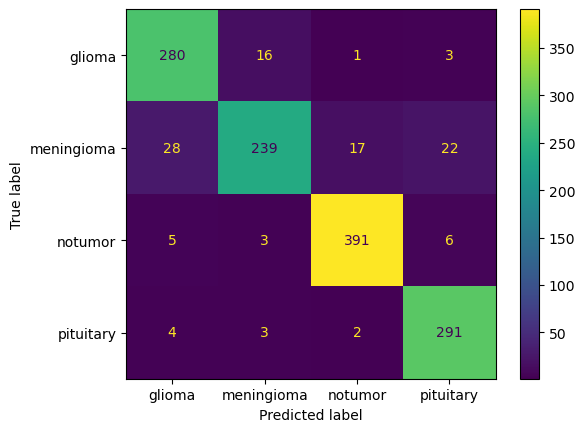

In [29]:
disp = ConfusionMatrixDisplay(conf_matrix,display_labels = ['glioma','meningioma','notumor','pituitary'])
disp.plot()

In [30]:
clas_rep = classification_report(y_true_classes,y_pred_classes)
print(clas_rep)

              precision    recall  f1-score   support

           0       0.88      0.93      0.91       300
           1       0.92      0.78      0.84       306
           2       0.95      0.97      0.96       405
           3       0.90      0.97      0.94       300

    accuracy                           0.92      1311
   macro avg       0.91      0.91      0.91      1311
weighted avg       0.92      0.92      0.91      1311



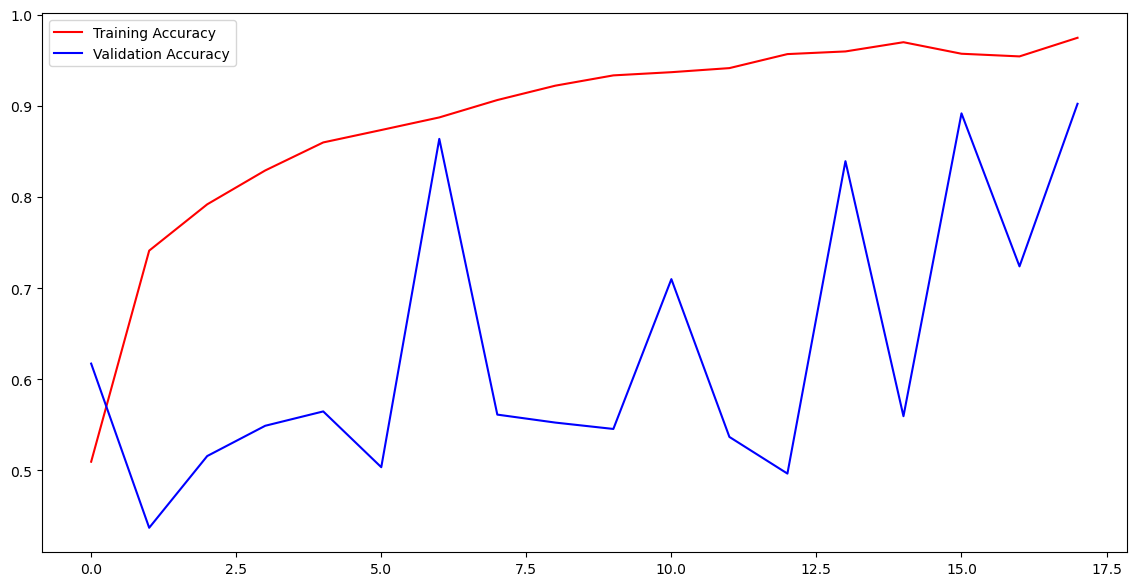

In [31]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs = range(len(acc))
fig = plt.figure(figsize=(14,7))
plt.plot(epochs,acc,'r',label="Training Accuracy")
plt.plot(epochs,val_acc,'b',label="Validation Accuracy")
plt.legend(loc='upper left')
plt.show()

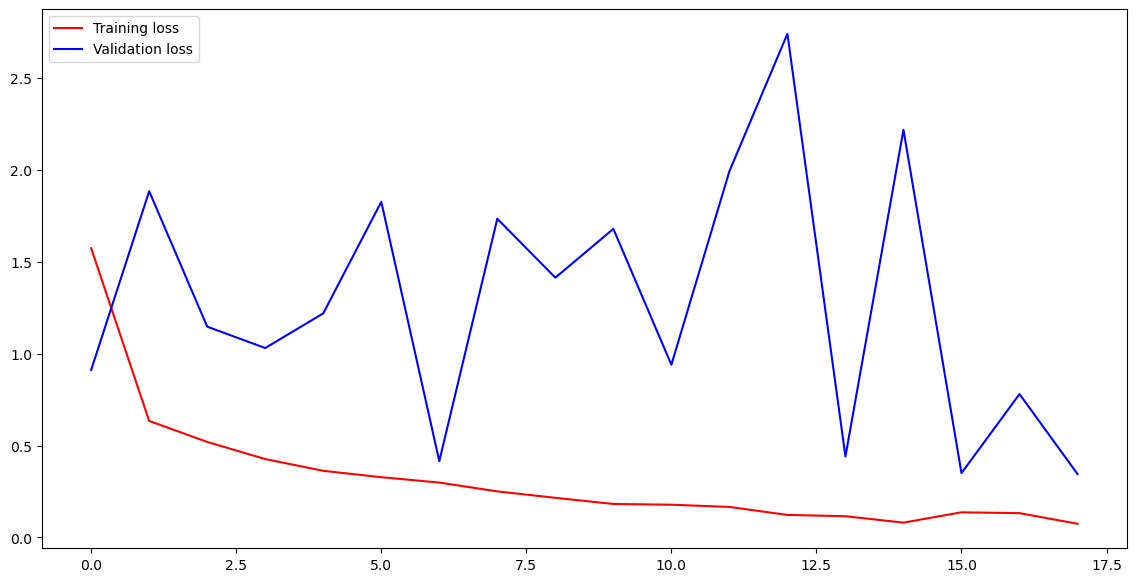

In [32]:
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(len(loss))
fig = plt.figure(figsize=(14,7))
plt.plot(epochs,loss,'r',label="Training loss")
plt.plot(epochs,val_loss,'b',label="Validation loss")
plt.legend(loc='upper left')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step


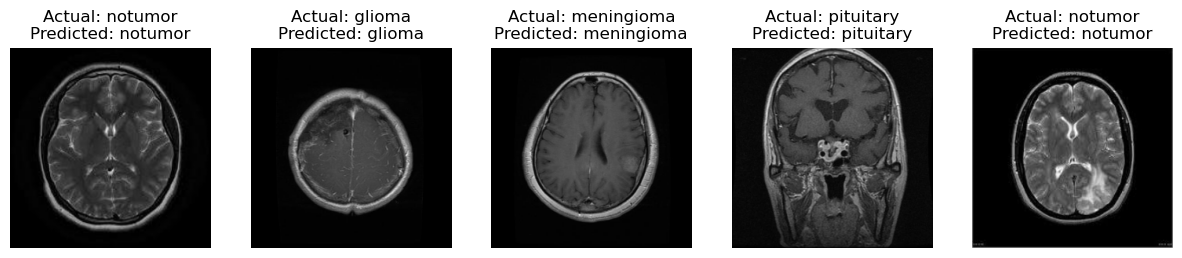

In [34]:
import random

# Selecting random images and their corresponding labels from the test set
num_samples = 5  # Number of samples to visualize
random_indexes = random.sample(range(len(x_test)), num_samples)

# Making predictions
predicted_labels = model.predict(x_test[random_indexes])
predicted_classes = np.argmax(predicted_labels, axis=1)
actual_classes = np.argmax(y_test[random_indexes], axis=1)

# Mapping numerical labels to their corresponding string labels
class_mapping = {0: 'glioma', 1: 'meningioma', 2: 'notumor', 3: 'pituitary'}

# Visualizing the results
plt.figure(figsize=(15, 10))
for i, idx in enumerate(random_indexes):
    plt.subplot(1, num_samples, i + 1)
    plt.imshow(x_test[idx])
    plt.title(f"Actual: {class_mapping[actual_classes[i]]}\nPredicted: {class_mapping[predicted_classes[i]]}")
    plt.axis('off')

plt.show()
